In [1]:
# ============================================================
# STEP 1: Setup & Imports
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)
import seaborn as sns

# Check GPU
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Output folder for plots (300 DPI, for your report)
PLOT_DIR = "/kaggle/working/plots"
os.makedirs(PLOT_DIR, exist_ok=True)
DPI = 300

CLASS_NAMES = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print("Setup complete. Plots will be saved to:", PLOT_DIR)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Setup complete. Plots will be saved to: /kaggle/working/plots


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1871s 11us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


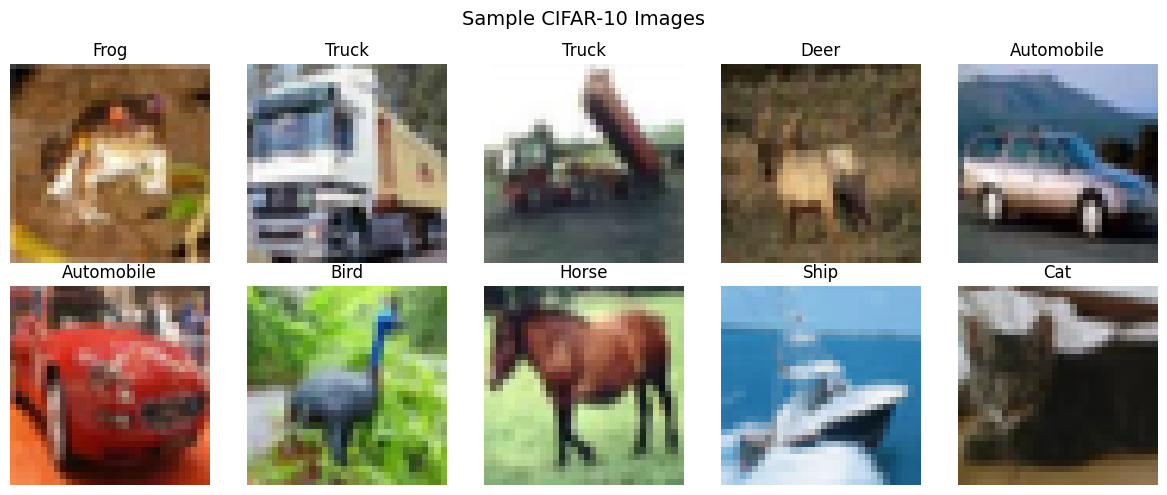


Saved: 1_sample_cifar10_images.png


In [2]:
# ============================================================
# STEP 2: Dataset Preparation (Task 1)
# ============================================================

# 1. Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 2. Normalize pixel values to [0,1]
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test, num_classes=10)

# 4. Print dataset dimensions
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

# 3. Display 10 sample images -> save as mandatory plot 1
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[y_train[i][0]])
    ax.axis("off")
plt.suptitle("Sample CIFAR-10 Images", fontsize=14)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/1_sample_cifar10_images.png", dpi=DPI, bbox_inches="tight")
plt.show()

print("\nSaved: 1_sample_cifar10_images.png")

In [3]:
# ============================================================
# STEP 3: Build Transfer Learning Model - ResNet50 (Task 2)
# ============================================================

IMG_SIZE = 32  # CIFAR native size; ResNet50 can accept this via include_top=False

# 1. Load pretrained ImageNet weights (exclude original classifier)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# 3. Freeze the convolutional base
base_model.trainable = False

# 4-6. Add GAP -> Dense(ReLU) -> Output(Softmax)
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

model_resnet50 = Model(inputs=base_model.input, outputs=outputs)

model_resnet50.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet50.summary()

total_params = model_resnet50.count_params()
print(f"\nTotal Parameters: {total_params:,}")

I0000 00:00:1787758124.489300      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787758124.492179      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Total Parameters: 24,114,826


In [4]:
# ============================================================
# STEP 4: Model Training (Task 3)
# ============================================================
import time

# ResNet50 needs its own preprocessing (mean-centering), not plain /255
x_train_resnet = preprocess_input(x_train.astype("float32").copy())
x_test_resnet  = preprocess_input(x_test.astype("float32").copy())

BATCH_SIZE = 32
EPOCHS = 15  # within the 10-20 range specified

start_time = time.time()

history_initial = model_resnet50.fit(
    x_train_resnet, y_train_cat,
    validation_data=(x_test_resnet, y_test_cat),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=1
)

initial_training_time = time.time() - start_time
print(f"\nInitial training time: {initial_training_time/60:.2f} minutes")

Epoch 1/15
  23/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3050 - loss: 3.7434  

I0000 00:00:1787758229.293938     137 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - accuracy: 0.6053 - loss: 1.1531 - val_accuracy: 0.6446 - val_loss: 1.0305
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.6791 - loss: 0.9113 - val_accuracy: 0.6383 - val_loss: 1.0277
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7131 - loss: 0.8075 - val_accuracy: 0.6535 - val_loss: 1.0047
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7428 - loss: 0.7231 - val_accuracy: 0.6561 - val_loss: 1.0254
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7724 - loss: 0.6356 - val_accuracy: 0.6553 - val_loss: 1.0874
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8017 - loss: 0.5572 - val_accuracy: 0.6487 - val_loss: 1.1500
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8282 - loss: 0.4829 - val_accuracy: 0.6468 - val_loss: 1.2723
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8520 - loss: 0.4194 - va

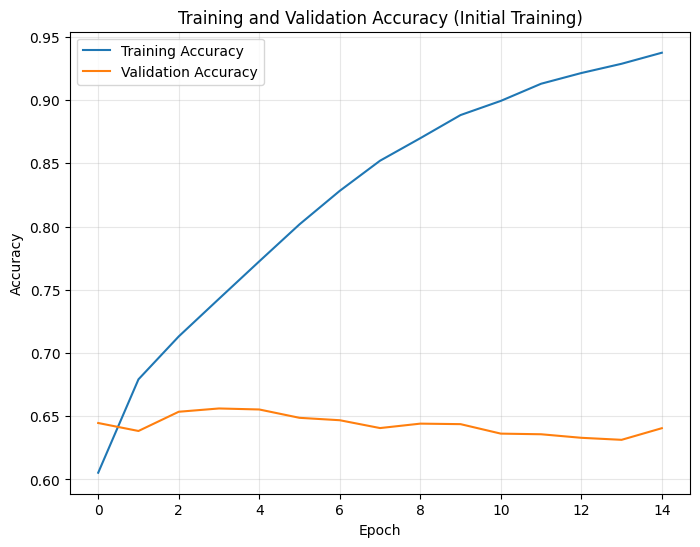

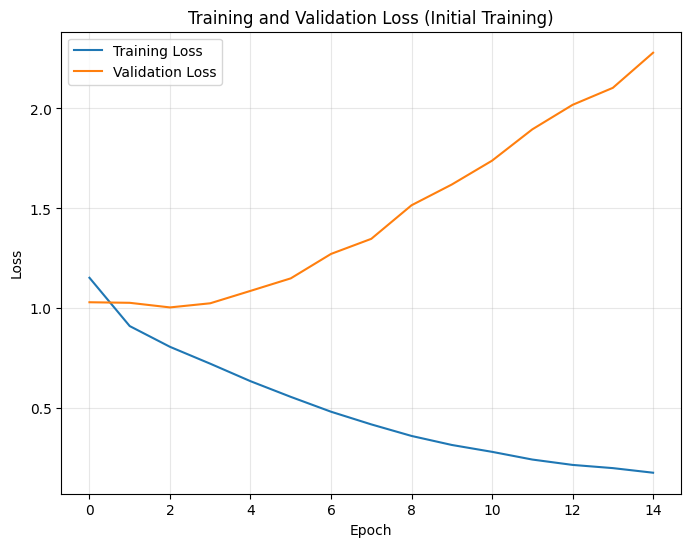

Saved: 2_3_training_validation_accuracy.png
Saved: 4_5_training_validation_loss.png

Final Training Accuracy: 0.9375
Final Validation Accuracy: 0.6405


In [5]:
# ============================================================
# STEP 5: Accuracy & Loss Plots (Mandatory Plots 2-5)
# ============================================================

# Plot 2 & 3: Training vs Validation Accuracy
plt.figure(figsize=(8, 6))
plt.plot(history_initial.history['accuracy'], label='Training Accuracy')
plt.plot(history_initial.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Initial Training)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{PLOT_DIR}/2_3_training_validation_accuracy.png", dpi=DPI, bbox_inches="tight")
plt.show()

# Plot 4 & 5: Training vs Validation Loss
plt.figure(figsize=(8, 6))
plt.plot(history_initial.history['loss'], label='Training Loss')
plt.plot(history_initial.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (Initial Training)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{PLOT_DIR}/4_5_training_validation_loss.png", dpi=DPI, bbox_inches="tight")
plt.show()

print("Saved: 2_3_training_validation_accuracy.png")
print("Saved: 4_5_training_validation_loss.png")

# Quick check of final epoch numbers
print(f"\nFinal Training Accuracy: {history_initial.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_initial.history['val_accuracy'][-1]:.4f}")

In [6]:
# ============================================================
# STEP 6: Fine-Tuning (Task 4)
# ============================================================

# 1. Unfreeze the last convolution block of ResNet50
base_model.trainable = True

# ResNet50's last block is roughly "conv5_block3" — freeze everything before it
fine_tune_at = None
for i, layer in enumerate(base_model.layers):
    if 'conv5_block3' in layer.name:
        if fine_tune_at is None:
            fine_tune_at = i
        continue

# Freeze all layers before the last block; unfreeze from there on
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

print(f"Unfroze layers from index {fine_tune_at} onward (conv5_block3 and beyond)")

# Recompile with a lower learning rate for fine-tuning (standard practice)
model_resnet50.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Train for another 5-10 epochs
FINE_TUNE_EPOCHS = 8

start_time = time.time()

history_finetune = model_resnet50.fit(
    x_train_resnet, y_train_cat,
    validation_data=(x_test_resnet, y_test_cat),
    batch_size=BATCH_SIZE,
    epochs=FINE_TUNE_EPOCHS,
    verbose=1
)

finetune_training_time = time.time() - start_time
total_training_time = initial_training_time + finetune_training_time
print(f"\nFine-tuning time: {finetune_training_time/60:.2f} minutes")
print(f"Total training time (initial + fine-tune): {total_training_time/60:.2f} minutes")

# 3. Compare accuracy before and after fine-tuning
print(f"\n--- Comparison ---")
print(f"Before fine-tuning - Val Accuracy: {history_initial.history['val_accuracy'][-1]:.4f}")
print(f"After fine-tuning  - Val Accuracy: {history_finetune.history['val_accuracy'][-1]:.4f}")

Unfroze layers from index 165 onward (conv5_block3 and beyond)
Epoch 1/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 17ms/step - accuracy: 0.9149 - loss: 0.2538 - val_accuracy: 0.6375 - val_loss: 2.0734
Epoch 2/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9513 - loss: 0.1471 - val_accuracy: 0.6425 - val_loss: 2.0734
Epoch 3/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9642 - loss: 0.1114 - val_accuracy: 0.6438 - val_loss: 2.1260
Epoch 4/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9733 - loss: 0.0883 - val_accuracy: 0.6504 - val_loss: 2.1133
Epoch 5/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9768 - loss: 0.0792 - val_accuracy: 0.6427 - val_loss: 2.1536
Epoch 6/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9829 - loss: 0.0628 - val_accuracy: 0.6495 - val_loss: 2.1798
Epoch 7/8
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9883 - loss: 0.0484 - val_accuracy: 0.6544 - val_loss: 2.2154
Epoch 8/8
1563/1563 

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step
PERFORMANCE METRICS (ResNet50)
Training Accuracy : 0.9890
Testing Accuracy  : 0.6533
Precision         : 0.6535
Recall            : 0.6533
F1-score          : 0.6530
Training Time     : 6.18 minutes
Total Parameters  : 24,114,826

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Airplane       0.69      0.70      0.70      1000
  Automobile       0.72      0.69      0.70      1000
        Bird       0.59      0.56      0.57      1000
         Cat       0.50      0.48      0.49      1000
        Deer       0.61      0.60      0.60      1000
         Dog       0.58      0.62      0.59      1000
        Frog       0.72      0.71      0.72      1000
       Horse       0.69      0.69      0.69      1000
        Ship       0.78      0.75      0.76      1000
       Truck       0.66      0.74      0.70      1000

    accuracy                           0.65     10000
   macro avg       0.65      0.65      0.65     10000


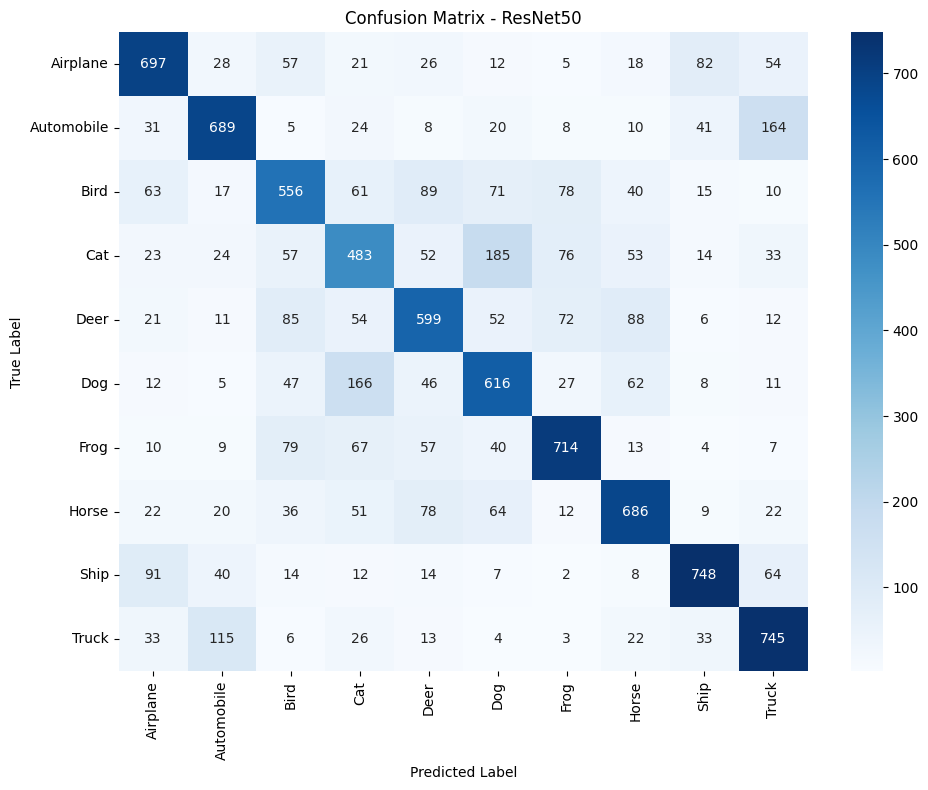


Saved: 6_confusion_matrix.png
Saved: classification_report.txt


In [7]:
# ============================================================
# STEP 7: Model Evaluation (Task 5)
# ============================================================

# Predictions
y_pred_probs = model_resnet50.predict(x_test_resnet, batch_size=BATCH_SIZE)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Metrics
test_accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("="*50)
print("PERFORMANCE METRICS (ResNet50)")
print("="*50)
print(f"Training Accuracy : {history_finetune.history['accuracy'][-1]:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-score          : {f1:.4f}")
print(f"Training Time     : {total_training_time/60:.2f} minutes")
print(f"Total Parameters  : {model_resnet50.count_params():,}")

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)

# Save classification report as text file (for documentation)
with open(f"{PLOT_DIR}/classification_report.txt", "w") as f:
    f.write(report)

# Plot 6: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - ResNet50')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/6_confusion_matrix.png", dpi=DPI, bbox_inches="tight")
plt.show()

print("\nSaved: 6_confusion_matrix.png")
print("Saved: classification_report.txt")

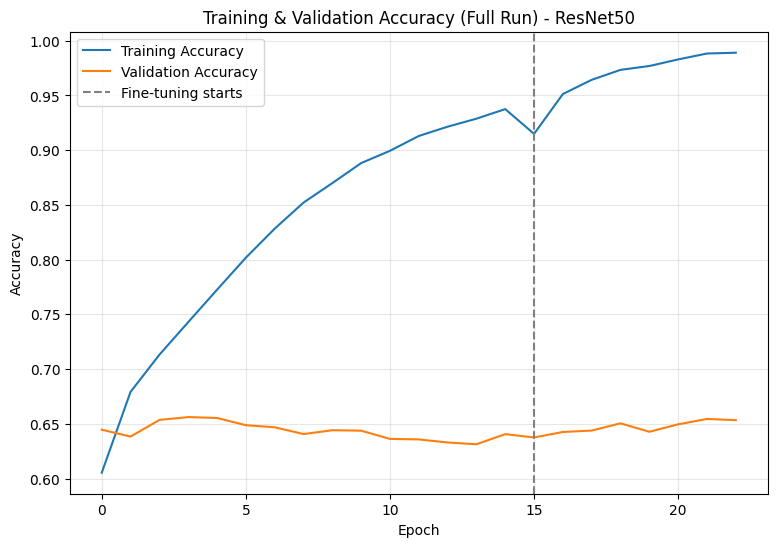

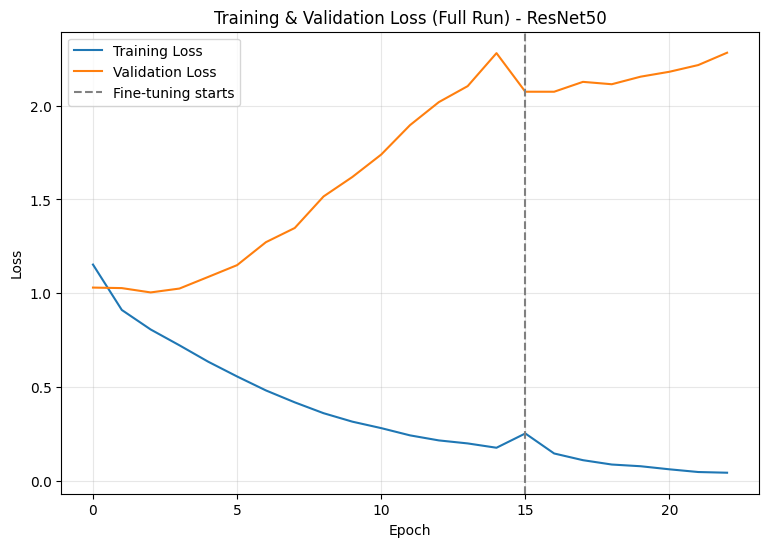

Saved: 2b_combined_accuracy.png
Saved: 4b_combined_loss.png

Total misclassified: 3467 out of 10000


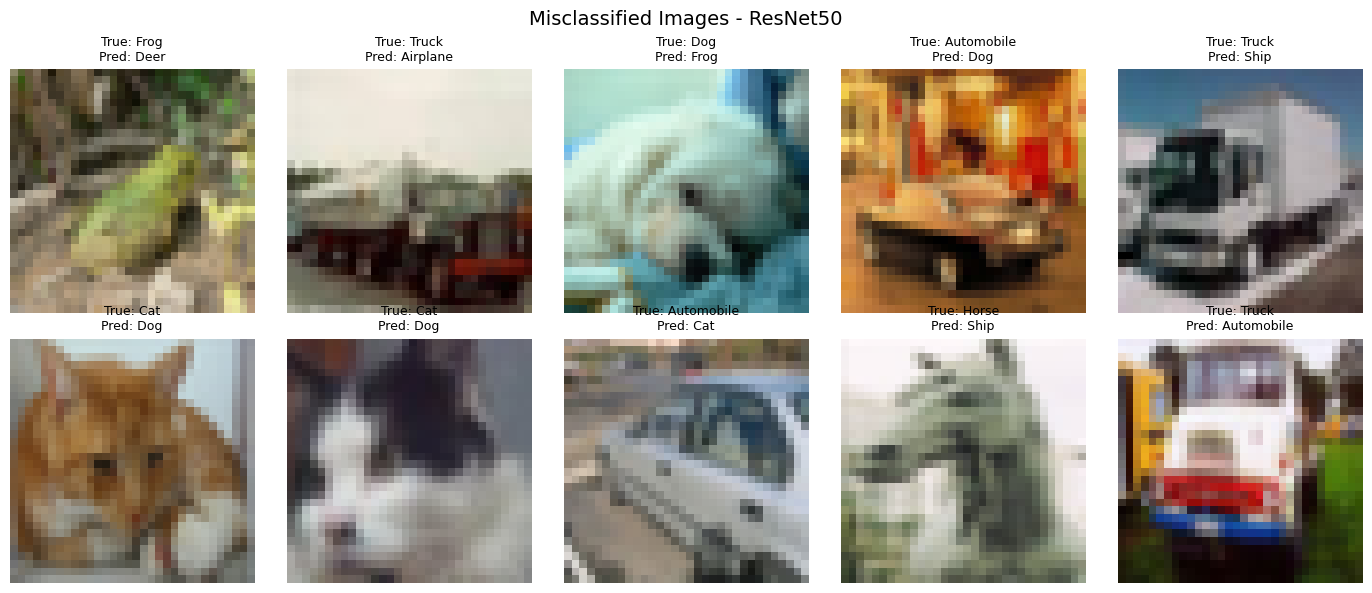

Saved: 7_misclassified_images.png


In [8]:
# ============================================================
# STEP 8: Combined Accuracy/Loss Plots (Initial + Fine-tune)
# ============================================================

# Stitch both training phases together for a full picture
combined_acc = history_initial.history['accuracy'] + history_finetune.history['accuracy']
combined_val_acc = history_initial.history['val_accuracy'] + history_finetune.history['val_accuracy']
combined_loss = history_initial.history['loss'] + history_finetune.history['loss']
combined_val_loss = history_initial.history['val_loss'] + history_finetune.history['val_loss']

fine_tune_start = len(history_initial.history['accuracy'])

# Combined Accuracy
plt.figure(figsize=(9, 6))
plt.plot(combined_acc, label='Training Accuracy')
plt.plot(combined_val_acc, label='Validation Accuracy')
plt.axvline(x=fine_tune_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training & Validation Accuracy (Full Run) - ResNet50')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{PLOT_DIR}/2b_combined_accuracy.png", dpi=DPI, bbox_inches="tight")
plt.show()

# Combined Loss
plt.figure(figsize=(9, 6))
plt.plot(combined_loss, label='Training Loss')
plt.plot(combined_val_loss, label='Validation Loss')
plt.axvline(x=fine_tune_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training & Validation Loss (Full Run) - ResNet50')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{PLOT_DIR}/4b_combined_loss.png", dpi=DPI, bbox_inches="tight")
plt.show()

print("Saved: 2b_combined_accuracy.png")
print("Saved: 4b_combined_loss.png")

# ============================================================
# Optional Plot 7: Misclassified Images
# ============================================================
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"\nTotal misclassified: {len(misclassified_idx)} out of {len(y_true)}")

n_show = min(10, len(misclassified_idx))
sample_idx = np.random.choice(misclassified_idx, n_show, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, (idx, ax) in enumerate(zip(sample_idx, axes.flat)):
    ax.imshow(x_test[idx])
    ax.set_title(f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}", fontsize=9)
    ax.axis("off")
plt.suptitle("Misclassified Images - ResNet50", fontsize=14)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/7_misclassified_images.png", dpi=DPI, bbox_inches="tight")
plt.show()

print("Saved: 7_misclassified_images.png")

In [9]:
# ============================================================
# STEP 9: Save ResNet50 Summary (for comparison table)
# ============================================================

results_summary = {}

results_summary['ResNet50'] = {
    'Parameters': model_resnet50.count_params(),
    'Training_Accuracy': history_finetune.history['accuracy'][-1],
    'Testing_Accuracy': test_accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1_score': f1,
    'Training_Time_min': total_training_time / 60
}

print("ResNet50 Results:")
for k, v in results_summary['ResNet50'].items():
    print(f"  {k}: {v}")

ResNet50 Results:
  Parameters: 24114826
  Training_Accuracy: 0.9889799952507019
  Testing_Accuracy: 0.6533
  Precision: 0.6535324629156354
  Recall: 0.6533
  F1_score: 0.6529771387906808
  Training_Time_min: 6.183531339963277


In [10]:
# ============================================================
# STEP 10: VGG16 - Full Pipeline (Tasks 2-5)
# ============================================================
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

# --- Task 2: Build model ---
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_vgg.trainable = False

x = GlobalAveragePooling2D()(base_vgg.output)
x = Dense(256, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)
model_vgg16 = Model(inputs=base_vgg.input, outputs=outputs)

model_vgg16.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])
model_vgg16.summary()

# --- Preprocessing ---
x_train_vgg = vgg_preprocess(x_train.astype("float32").copy())
x_test_vgg  = vgg_preprocess(x_test.astype("float32").copy())

# --- Task 3: Initial training ---
start_time = time.time()
history_vgg_initial = model_vgg16.fit(
    x_train_vgg, y_train_cat,
    validation_data=(x_test_vgg, y_test_cat),
    batch_size=32, epochs=15, verbose=1
)
vgg_initial_time = time.time() - start_time

# --- Task 4: Fine-tuning (unfreeze last conv block) ---
base_vgg.trainable = True
fine_tune_at = None
for i, layer in enumerate(base_vgg.layers):
    if 'block5' in layer.name:
        if fine_tune_at is None:
            fine_tune_at = i
        continue
for layer in base_vgg.layers[:fine_tune_at]:
    layer.trainable = False

model_vgg16.compile(optimizer=Adam(learning_rate=0.0001),
                     loss='categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
history_vgg_finetune = model_vgg16.fit(
    x_train_vgg, y_train_cat,
    validation_data=(x_test_vgg, y_test_cat),
    batch_size=32, epochs=8, verbose=1
)
vgg_finetune_time = time.time() - start_time
vgg_total_time = vgg_initial_time + vgg_finetune_time
print(f"\nVGG16 total training time: {vgg_total_time/60:.2f} min")

# --- Task 5: Evaluation ---
y_pred_vgg = np.argmax(model_vgg16.predict(x_test_vgg, batch_size=32), axis=1)

vgg_test_acc = accuracy_score(y_true, y_pred_vgg)
vgg_precision = precision_score(y_true, y_pred_vgg, average='weighted')
vgg_recall = recall_score(y_true, y_pred_vgg, average='weighted')
vgg_f1 = f1_score(y_true, y_pred_vgg, average='weighted')

print(f"VGG16 Test Accuracy: {vgg_test_acc:.4f} | Precision: {vgg_precision:.4f} | Recall: {vgg_recall:.4f} | F1: {vgg_f1:.4f}")

results_summary['VGG16'] = {
    'Parameters': model_vgg16.count_params(),
    'Training_Accuracy': history_vgg_finetune.history['accuracy'][-1],
    'Testing_Accuracy': vgg_test_acc,
    'Precision': vgg_precision,
    'Recall': vgg_recall,
    'F1_score': vgg_f1,
    'Training_Time_min': vgg_total_time / 60
}

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.5644 - loss: 1.8204 - val_accuracy: 0.6180 - val_loss: 1.1223
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6682 - loss: 0.9676 - val_accuracy: 0.6377 - val_loss: 1.0821
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6973 - loss: 0.8685 - val_accuracy: 0.6361 - val_loss: 1.1041
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7221 - loss: 0.7994 - val_accuracy: 0.6408 - val_loss: 1.1162
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7436 - loss: 0.7329 - val_accuracy: 0.6408 - val_loss: 1.1685
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7679 - loss: 0.6631 - val_accuracy: 0.6365 - val_loss: 1.2352
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7899 - loss: 0.5988 - val_accuracy: 0.6510 - val_loss: 1.3001
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8108 - loss: 

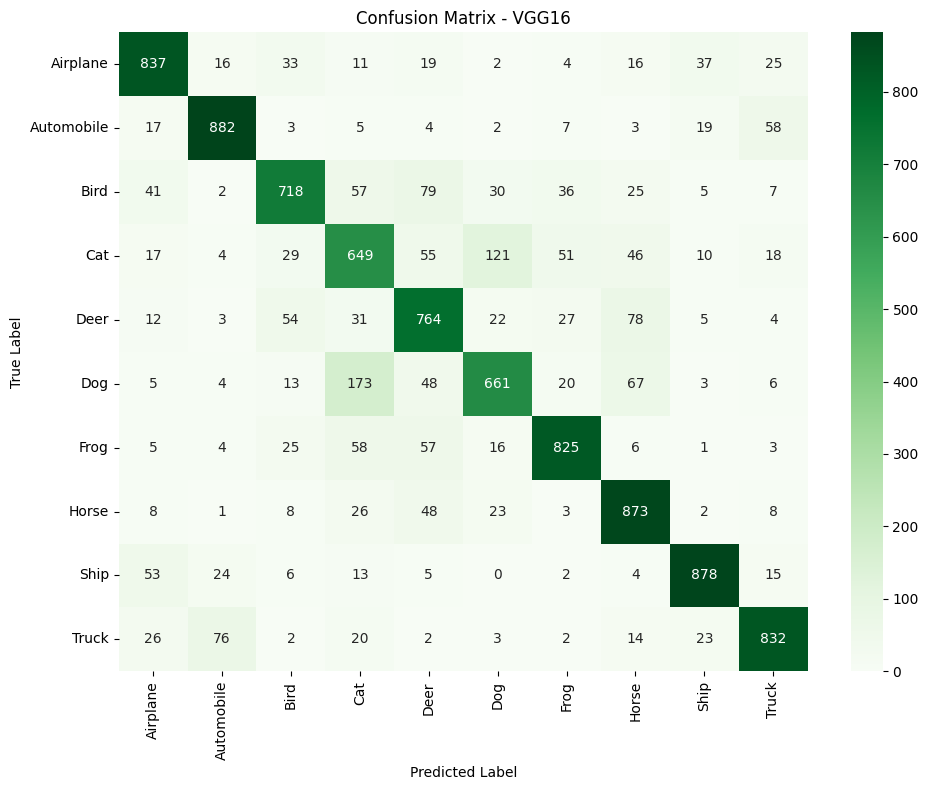

Saved: 6b_confusion_matrix_vgg16.png


In [11]:
# ============================================================
# STEP 11: VGG16 Confusion Matrix
# ============================================================
cm_vgg = confusion_matrix(y_true, y_pred_vgg)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - VGG16')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/6b_confusion_matrix_vgg16.png", dpi=DPI, bbox_inches="tight")
plt.show()

print("Saved: 6b_confusion_matrix_vgg16.png")

In [12]:
# ============================================================
# STEP 12: MobileNetV2 - Full Pipeline (Tasks 2-5)
# ============================================================
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

# --- Task 2: Build model ---
base_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_mobilenet.trainable = False

x = GlobalAveragePooling2D()(base_mobilenet.output)
x = Dense(256, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)
model_mobilenet = Model(inputs=base_mobilenet.input, outputs=outputs)

model_mobilenet.compile(optimizer=Adam(learning_rate=0.001),
                         loss='categorical_crossentropy', metrics=['accuracy'])
model_mobilenet.summary()

# --- Preprocessing ---
x_train_mob = mobilenet_preprocess(x_train.astype("float32").copy())
x_test_mob  = mobilenet_preprocess(x_test.astype("float32").copy())

# --- Task 3: Initial training ---
start_time = time.time()
history_mob_initial = model_mobilenet.fit(
    x_train_mob, y_train_cat,
    validation_data=(x_test_mob, y_test_cat),
    batch_size=32, epochs=15, verbose=1
)
mob_initial_time = time.time() - start_time

# --- Task 4: Fine-tuning (unfreeze last block) ---
base_mobilenet.trainable = True
fine_tune_at = len(base_mobilenet.layers) - 20  # unfreeze last ~20 layers (MobileNetV2 has no clean "block5" naming)
for layer in base_mobilenet.layers[:fine_tune_at]:
    layer.trainable = False

model_mobilenet.compile(optimizer=Adam(learning_rate=0.0001),
                         loss='categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
history_mob_finetune = model_mobilenet.fit(
    x_train_mob, y_train_cat,
    validation_data=(x_test_mob, y_test_cat),
    batch_size=32, epochs=8, verbose=1
)
mob_finetune_time = time.time() - start_time
mob_total_time = mob_initial_time + mob_finetune_time
print(f"\nMobileNetV2 total training time: {mob_total_time/60:.2f} min")

# --- Task 5: Evaluation ---
y_pred_mob = np.argmax(model_mobilenet.predict(x_test_mob, batch_size=32), axis=1)

mob_test_acc = accuracy_score(y_true, y_pred_mob)
mob_precision = precision_score(y_true, y_pred_mob, average='weighted')
mob_recall = recall_score(y_true, y_pred_mob, average='weighted')
mob_f1 = f1_score(y_true, y_pred_mob, average='weighted')

print(f"MobileNetV2 Test Accuracy: {mob_test_acc:.4f} | Precision: {mob_precision:.4f} | Recall: {mob_recall:.4f} | F1: {mob_f1:.4f}")

results_summary['MobileNetV2'] = {
    'Parameters': model_mobilenet.count_params(),
    'Training_Accuracy': history_mob_finetune.history['accuracy'][-1],
    'Testing_Accuracy': mob_test_acc,
    'Precision': mob_precision,
    'Recall': mob_recall,
    'F1_score': mob_f1,
    'Training_Time_min': mob_total_time / 60
}

/tmp/ipykernel_58/3023693451.py:8: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

...

Epoch 1/15


2026-08-26 16:11:05.465843: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 16:11:05.623359: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 16:11:05.759479: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2624 - loss: 2.0428

2026-08-26 16:11:23.065550: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 16:11:23.201775: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.2809 - loss: 1.9767 - val_accuracy: 0.2929 - val_loss: 1.9268
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3068 - loss: 1.8935 - val_accuracy: 0.2997 - val_loss: 1.9041
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3189 - loss: 1.8561 - val_accuracy: 0.3110 - val_loss: 1.8902
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3303 - loss: 1.8271 - val_accuracy: 0.3088 - val_loss: 1.8857
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3410 - loss: 1.8019 - val_accuracy: 0.3147 - val_loss: 1.8839
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3488 - loss: 1.7793 - val_accuracy: 0.3150 - val_loss: 1.8914
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3556 - loss: 1.7589 - val_accuracy: 0.3110 - val_loss: 1.8968
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3625 - loss: 1.7406 - va

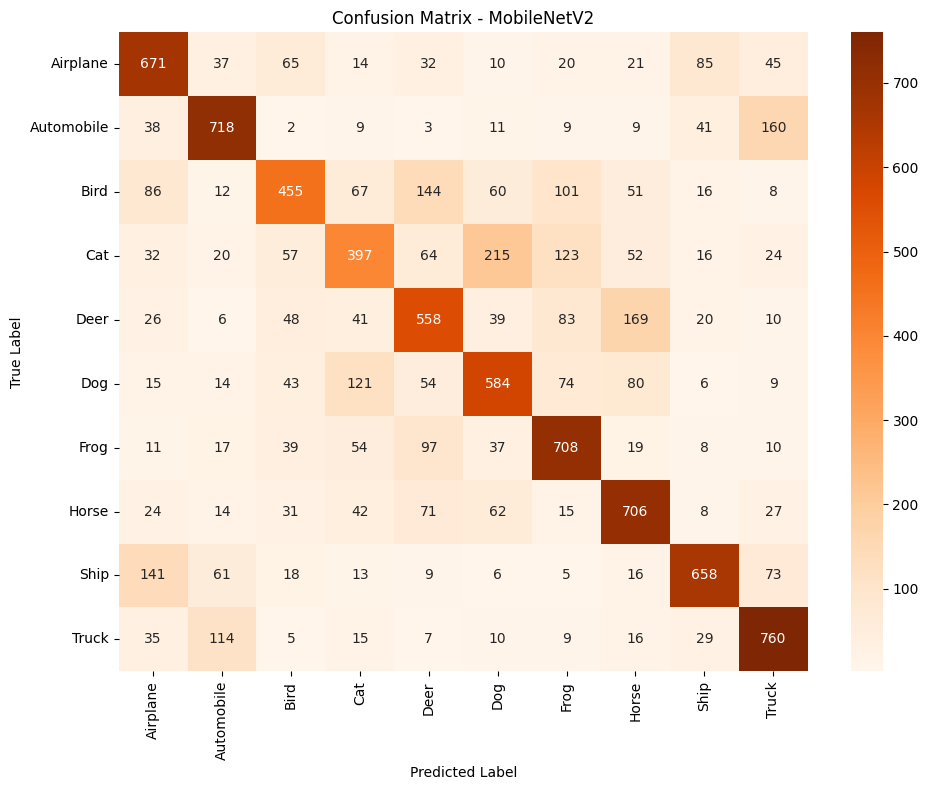

Saved: 6c_confusion_matrix_mobilenetv2.png


In [13]:
# ============================================================
# STEP 13: MobileNetV2 Confusion Matrix
# ============================================================
cm_mob = confusion_matrix(y_true, y_pred_mob)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mob, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - MobileNetV2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/6c_confusion_matrix_mobilenetv2.png", dpi=DPI, bbox_inches="tight")
plt.show()

print("Saved: 6c_confusion_matrix_mobilenetv2.png")

In [14]:
# ============================================================
# STEP 14: GoogleNet (InceptionV3) - Full Pipeline (Tasks 2-5)
# ============================================================
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess

IMG_SIZE_INCEPTION = 75  # minimum accepted size

# --- Resize data (do this once, reuse for train/finetune/eval) ---
def resize_batch(images, size):
    return tf.image.resize(images, (size, size)).numpy()

# Resize in chunks to avoid memory spikes
def resize_in_chunks(images, size, chunk=5000):
    out = []
    for i in range(0, len(images), chunk):
        out.append(resize_batch(images[i:i+chunk], size))
    return np.concatenate(out)

x_train_resized = resize_in_chunks(x_train, IMG_SIZE_INCEPTION)
x_test_resized  = resize_in_chunks(x_test, IMG_SIZE_INCEPTION)

x_train_incep = inception_preprocess(x_train_resized.astype("float32"))
x_test_incep  = inception_preprocess(x_test_resized.astype("float32"))

# --- Task 2: Build model ---
base_inception = InceptionV3(weights='imagenet', include_top=False,
                              input_shape=(IMG_SIZE_INCEPTION, IMG_SIZE_INCEPTION, 3))
base_inception.trainable = False

x = GlobalAveragePooling2D()(base_inception.output)
x = Dense(256, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)
model_inception = Model(inputs=base_inception.input, outputs=outputs)

model_inception.compile(optimizer=Adam(learning_rate=0.001),
                         loss='categorical_crossentropy', metrics=['accuracy'])
model_inception.summary()

# --- Task 3: Initial training ---
start_time = time.time()
history_incep_initial = model_inception.fit(
    x_train_incep, y_train_cat,
    validation_data=(x_test_incep, y_test_cat),
    batch_size=32, epochs=15, verbose=1
)
incep_initial_time = time.time() - start_time

# --- Task 4: Fine-tuning (unfreeze last inception block) ---
base_inception.trainable = True
fine_tune_at = len(base_inception.layers) - 30  # unfreeze last ~30 layers
for layer in base_inception.layers[:fine_tune_at]:
    layer.trainable = False

model_inception.compile(optimizer=Adam(learning_rate=0.0001),
                         loss='categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
history_incep_finetune = model_inception.fit(
    x_train_incep, y_train_cat,
    validation_data=(x_test_incep, y_test_cat),
    batch_size=32, epochs=8, verbose=1
)
incep_finetune_time = time.time() - start_time
incep_total_time = incep_initial_time + incep_finetune_time
print(f"\nInceptionV3 total training time: {incep_total_time/60:.2f} min")

# --- Task 5: Evaluation ---
y_pred_incep = np.argmax(model_inception.predict(x_test_incep, batch_size=32), axis=1)

incep_test_acc = accuracy_score(y_true, y_pred_incep)
incep_precision = precision_score(y_true, y_pred_incep, average='weighted')
incep_recall = recall_score(y_true, y_pred_incep, average='weighted')
incep_f1 = f1_score(y_true, y_pred_incep, average='weighted')

print(f"InceptionV3 Test Accuracy: {incep_test_acc:.4f} | Precision: {incep_precision:.4f} | Recall: {incep_recall:.4f} | F1: {incep_f1:.4f}")

results_summary['GoogleNet'] = {
    'Parameters': model_inception.count_params(),
    'Training_Accuracy': history_incep_finetune.history['accuracy'][-1],
    'Testing_Accuracy': incep_test_acc,
    'Precision': incep_precision,
    'Recall': incep_recall,
    'F1_score': incep_f1,
    'Training_Time_min': incep_total_time / 60
}

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 37, 37,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 37, 37,    │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 35, 35,    │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 35, 35,    │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 17, 17,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 17, 17,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 15, 15,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 22,329,898 (85.18 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 27ms/step - accuracy: 0.6071 - loss: 1.1316 - val_accuracy: 0.6378 - val_loss: 1.0344
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.6812 - loss: 0.9056 - val_accuracy: 0.6544 - val_loss: 1.0031
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7258 - loss: 0.7792 - val_accuracy: 0.6528 - val_loss: 1.0228
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7685 - loss: 0.6545 - val_accuracy: 0.6570 - val_loss: 1.0545
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.8137 - loss: 0.5325 - val_accuracy: 0.6514 - val_loss: 1.1262
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.8551 - loss: 0.4152 - val_accuracy: 0.6453 - val_loss: 1.2523
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.8926 - loss: 0.3139 - val_accuracy: 0.6343 - val_loss: 1.4330
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.9194 -

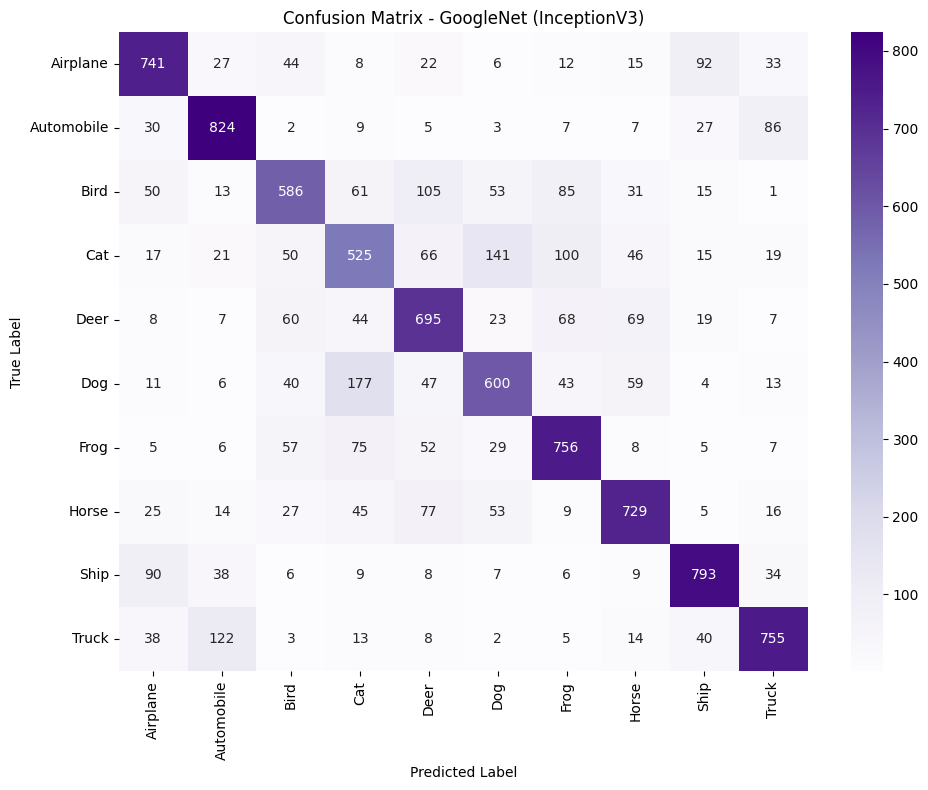

Saved: 6d_confusion_matrix_googlenet.png


In [15]:
# ============================================================
# STEP 15: GoogleNet (InceptionV3) Confusion Matrix
# ============================================================
cm_incep = confusion_matrix(y_true, y_pred_incep)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_incep, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - GoogleNet (InceptionV3)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/6d_confusion_matrix_googlenet.png", dpi=DPI, bbox_inches="tight")
plt.show()

print("Saved: 6d_confusion_matrix_googlenet.png")

In [16]:
# ============================================================
# STEP 16: LeNet-5 - Built & Trained from Scratch
# ============================================================
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Input

# LeNet-5 architecture (adapted for 32x32x3 CIFAR input, original was grayscale 32x32)
inputs = Input(shape=(32, 32, 3))
x = Conv2D(6, (5,5), activation='tanh', padding='same')(inputs)
x = AveragePooling2D((2,2))(x)
x = Conv2D(16, (5,5), activation='tanh')(x)
x = AveragePooling2D((2,2))(x)
x = Flatten()(x)
x = Dense(120, activation='tanh')(x)
x = Dense(84, activation='tanh')(x)
outputs = Dense(10, activation='softmax')(x)

model_lenet = Model(inputs=inputs, outputs=outputs)
model_lenet.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])
model_lenet.summary()

# Use plain normalized data (no special preprocessing needed for from-scratch model)
start_time = time.time()
history_lenet = model_lenet.fit(
    x_train_norm, y_train_cat,
    validation_data=(x_test_norm, y_test_cat),
    batch_size=32, epochs=20, verbose=1
)
lenet_time = time.time() - start_time
print(f"\nLeNet-5 training time: {lenet_time/60:.2f} min")

# Evaluation
y_pred_lenet = np.argmax(model_lenet.predict(x_test_norm, batch_size=32), axis=1)

lenet_test_acc = accuracy_score(y_true, y_pred_lenet)
lenet_precision = precision_score(y_true, y_pred_lenet, average='weighted')
lenet_recall = recall_score(y_true, y_pred_lenet, average='weighted')
lenet_f1 = f1_score(y_true, y_pred_lenet, average='weighted')

print(f"LeNet-5 Test Accuracy: {lenet_test_acc:.4f} | Precision: {lenet_precision:.4f} | Recall: {lenet_recall:.4f} | F1: {lenet_f1:.4f}")

results_summary['LeNet-5'] = {
    'Parameters': model_lenet.count_params(),
    'Training_Accuracy': history_lenet.history['accuracy'][-1],
    'Testing_Accuracy': lenet_test_acc,
    'Precision': lenet_precision,
    'Recall': lenet_recall,
    'F1_score': lenet_f1,
    'Training_Time_min': lenet_time / 60
}

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_9             │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_10            │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,126 (324.71 KB)

 Trainable params: 83,126 (324.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.3777 - loss: 1.7531 - val_accuracy: 0.4363 - val_loss: 1.5973
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4648 - loss: 1.5091 - val_accuracy: 0.4777 - val_loss: 1.4786
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5086 - loss: 1.3904 - val_accuracy: 0.5058 - val_loss: 1.3817
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5346 - loss: 1.3122 - val_accuracy: 0.5146 - val_loss: 1.3582
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5521 - loss: 1.2564 - val_accuracy: 0.5128 - val_loss: 1.3861
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5721 - loss: 1.2076 - val_accuracy: 0.5300 - val_loss: 1.3233
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5878 - loss: 1.1615 - val_accuracy: 0.5396 - val_loss: 1.3075
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6025 - loss: 1.1208 -

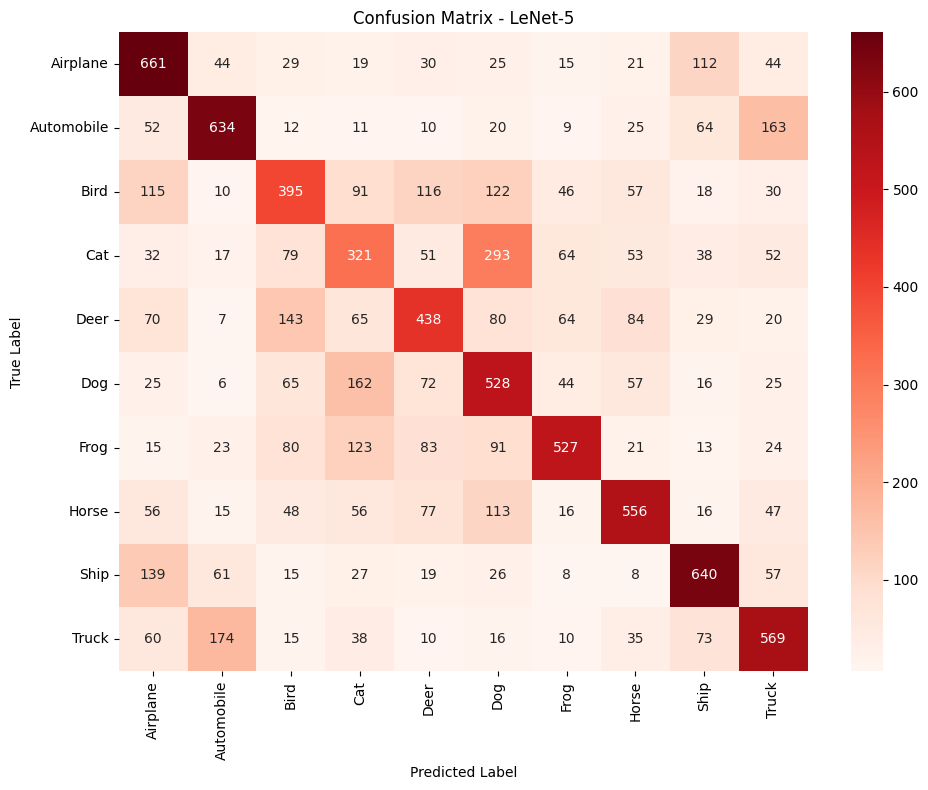

Saved: 6e_confusion_matrix_lenet5.png


In [17]:
# ============================================================
# STEP 17: LeNet-5 Confusion Matrix
# ============================================================
cm_lenet = confusion_matrix(y_true, y_pred_lenet)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lenet, annot=True, fmt='d', cmap='Reds',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - LeNet-5')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/6e_confusion_matrix_lenet5.png", dpi=DPI, bbox_inches="tight")
plt.show()

print("Saved: 6e_confusion_matrix_lenet5.png")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_11            │ (None, 16, 16, 64)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_12            │ (None, 8, 8, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_100 (Conv2D)             │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_96          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_13            │ (None, 4, 4, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,282,378 (20.15 MB)

 Trainable params: 5,281,482 (20.15 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.4742 - loss: 1.4992 - val_accuracy: 0.5776 - val_loss: 1.1965
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6592 - loss: 0.9847 - val_accuracy: 0.6701 - val_loss: 0.9558
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7277 - loss: 0.8078 - val_accuracy: 0.6752 - val_loss: 0.9565
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7672 - loss: 0.6894 - val_accuracy: 0.7081 - val_loss: 0.8627
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7964 - loss: 0.6077 - val_accuracy: 0.7793 - val_loss: 0.6667
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8195 - loss: 0.5318 - val_accuracy: 0.4804 - val_loss: 1.9461
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8421 - loss: 0.4712 - val_accuracy: 0.7946 - val_loss: 0.6472
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.8601 - loss: 

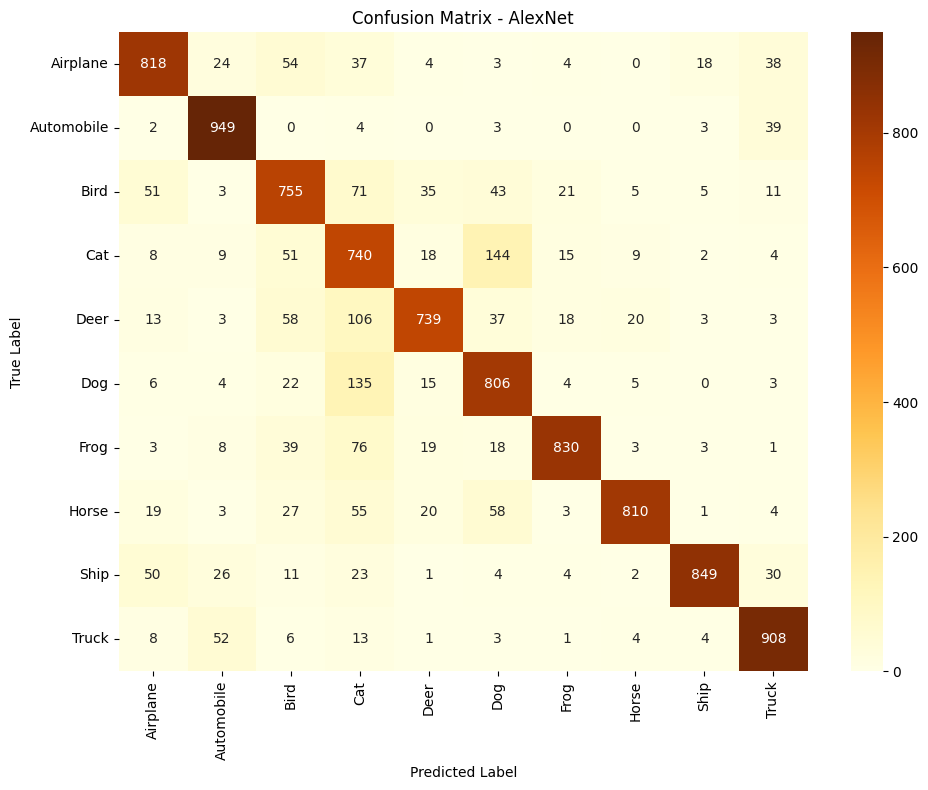

Saved: 6f_confusion_matrix_alexnet.png


In [18]:
# ============================================================
# STEP 18: AlexNet - Built & Trained from Scratch
# ============================================================
from tensorflow.keras.layers import BatchNormalization, Dropout

# AlexNet adapted for CIFAR's small 32x32 input (original used 227x227 -> strides/kernels scaled down)
inputs = Input(shape=(32, 32, 3))
x = Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = AveragePooling2D((2,2))(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = AveragePooling2D((2,2))(x)

x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = AveragePooling2D((2,2))(x)

x = Flatten()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(10, activation='softmax')(x)

model_alexnet = Model(inputs=inputs, outputs=outputs)
model_alexnet.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy', metrics=['accuracy'])
model_alexnet.summary()

start_time = time.time()
history_alexnet = model_alexnet.fit(
    x_train_norm, y_train_cat,
    validation_data=(x_test_norm, y_test_cat),
    batch_size=32, epochs=20, verbose=1
)
alexnet_time = time.time() - start_time
print(f"\nAlexNet training time: {alexnet_time/60:.2f} min")

# Evaluation
y_pred_alexnet = np.argmax(model_alexnet.predict(x_test_norm, batch_size=32), axis=1)

alexnet_test_acc = accuracy_score(y_true, y_pred_alexnet)
alexnet_precision = precision_score(y_true, y_pred_alexnet, average='weighted')
alexnet_recall = recall_score(y_true, y_pred_alexnet, average='weighted')
alexnet_f1 = f1_score(y_true, y_pred_alexnet, average='weighted')

print(f"AlexNet Test Accuracy: {alexnet_test_acc:.4f} | Precision: {alexnet_precision:.4f} | Recall: {alexnet_recall:.4f} | F1: {alexnet_f1:.4f}")

results_summary['AlexNet'] = {
    'Parameters': model_alexnet.count_params(),
    'Training_Accuracy': history_alexnet.history['accuracy'][-1],
    'Testing_Accuracy': alexnet_test_acc,
    'Precision': alexnet_precision,
    'Recall': alexnet_recall,
    'F1_score': alexnet_f1,
    'Training_Time_min': alexnet_time / 60
}

# Confusion matrix
cm_alexnet = confusion_matrix(y_true, y_pred_alexnet)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_alexnet, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix - AlexNet')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/6f_confusion_matrix_alexnet.png", dpi=DPI, bbox_inches="tight")
plt.show()

print("Saved: 6f_confusion_matrix_alexnet.png")

    Model Parameters Accuracy (%) Training Time (min)
  LeNet-5     83,126        52.69                1.83
  AlexNet  5,282,378        82.04                4.87
    VGG16 14,848,586        79.19                6.49
GoogleNet 22,329,898        70.04               11.15
 ResNet50 24,114,826        65.33                6.18

Saved: comparison_table.csv, full_metrics_table.csv


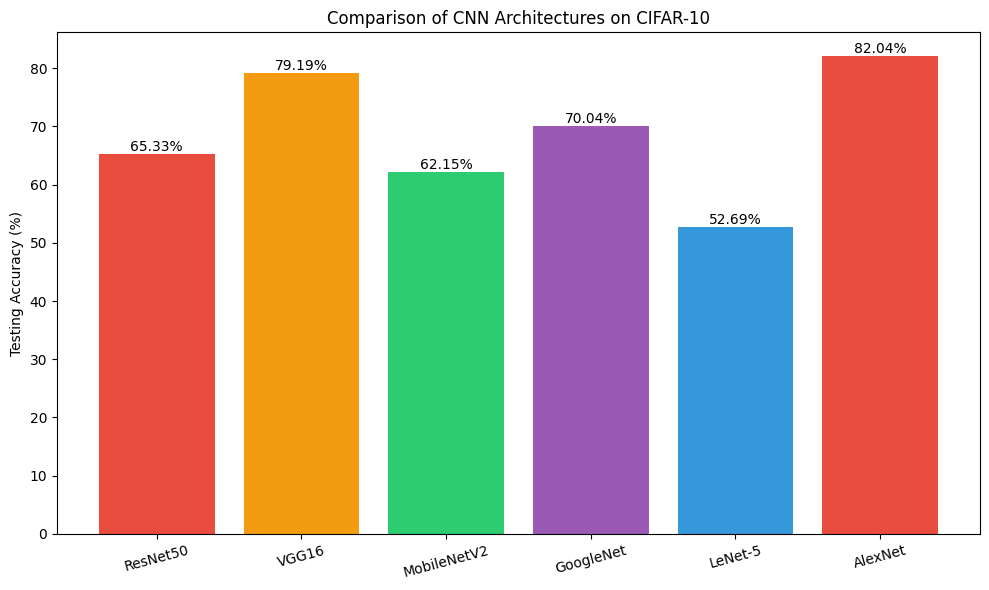

Saved: 8_model_comparison_accuracy.png


In [19]:
# ============================================================
# STEP 19: Final Comparison Table (Section 18.2) + Summary Chart
# ============================================================
import pandas as pd

# Build the comparison table
table_rows = []
for model_name in ['LeNet-5', 'AlexNet', 'VGG16', 'GoogleNet', 'ResNet50']:
    r = results_summary[model_name]
    table_rows.append({
        'Model': model_name,
        'Parameters': f"{r['Parameters']:,}",
        'Accuracy (%)': f"{r['Testing_Accuracy']*100:.2f}",
        'Training Time (min)': f"{r['Training_Time_min']:.2f}"
    })

comparison_df = pd.DataFrame(table_rows)
print(comparison_df.to_string(index=False))

# Save as CSV for your report
comparison_df.to_csv(f"{PLOT_DIR}/comparison_table.csv", index=False)

# Full 18.1-style metrics table too (all models, all metrics)
full_rows = []
for model_name, r in results_summary.items():
    full_rows.append({
        'Model': model_name,
        'Training_Accuracy': f"{r['Training_Accuracy']:.4f}",
        'Testing_Accuracy': f"{r['Testing_Accuracy']:.4f}",
        'Precision': f"{r['Precision']:.4f}",
        'Recall': f"{r['Recall']:.4f}",
        'F1_score': f"{r['F1_score']:.4f}",
        'Training_Time_min': f"{r['Training_Time_min']:.2f}",
        'Parameters': r['Parameters']
    })
full_df = pd.DataFrame(full_rows)
full_df.to_csv(f"{PLOT_DIR}/full_metrics_table.csv", index=False)
print("\nSaved: comparison_table.csv, full_metrics_table.csv")

# --- Summary bar chart: Accuracy comparison across all models ---
models_list = list(results_summary.keys())
accuracies = [results_summary[m]['Testing_Accuracy']*100 for m in models_list]

plt.figure(figsize=(10, 6))
bars = plt.bar(models_list, accuracies, color=['#e74c3c','#f39c12','#2ecc71','#9b59b6','#3498db'])
plt.ylabel('Testing Accuracy (%)')
plt.title('Comparison of CNN Architectures on CIFAR-10')
plt.xticks(rotation=15)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f'{acc:.2f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/8_model_comparison_accuracy.png", dpi=DPI, bbox_inches="tight")
plt.show()

print("Saved: 8_model_comparison_accuracy.png")

In [20]:
# ============================================================
# STEP 20: Zip all plots for download
# ============================================================
import shutil

shutil.make_archive("/kaggle/working/experiment4_plots", 'zip', PLOT_DIR)
print("Zip created at: /kaggle/working/experiment4_plots.zip")
print("\nFiles included:")
for f in sorted(os.listdir(PLOT_DIR)):
    print(" -", f)

Zip created at: /kaggle/working/experiment4_plots.zip

Files included:
 - 1_sample_cifar10_images.png
 - 2_3_training_validation_accuracy.png
 - 2b_combined_accuracy.png
 - 4_5_training_validation_loss.png
 - 4b_combined_loss.png
 - 6_confusion_matrix.png
 - 6b_confusion_matrix_vgg16.png
 - 6c_confusion_matrix_mobilenetv2.png
 - 6d_confusion_matrix_googlenet.png
 - 6e_confusion_matrix_lenet5.png
 - 6f_confusion_matrix_alexnet.png
 - 7_misclassified_images.png
 - 8_model_comparison_accuracy.png
 - classification_report.txt
 - comparison_table.csv
 - full_metrics_table.csv
